In [ ]:
import os
import math
import pickle
import sys

import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [ ]:
project_root = "../../../.."

#Set error rate level for this analysis
error_rate_level = "typical" #error condition to test: "typical", "high", "stress"

# Toggle: include 60bp dataset (only DeepCDS models available for 60bp)
run_30_bp_analysis = False  # Options: True, False; True if wanting to evalaute of CDSs down to 30bp (only DeepCDS models)

#Load data if already processed; set to False to re-run data processing and overwrite cached results
LOAD_PROCESSED_DATA = True

In [ ]:
if error_rate_level == "typical":
    indel_rate = "5e-06"
    sub_rate = "0.004"
elif error_rate_level == "high":
    indel_rate = "1.25e-05"
    sub_rate = "0.01"
elif error_rate_level == "stress":
    indel_rate = "3.75e-05"
    sub_rate = "0.03"
else:
    raise ValueError(f"Invalid error_rate_level: {error_rate_level}. Must be one of 'typical', 'high', 'stress'")

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
tt4_families = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in tt4_families else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

print(f"Total test accessions: {len(all_test_accessions)}")
print(f"Error rates: indel={indel_rate}, substitution={sub_rate}")
print(f"Run evaluation down to 30bp: {run_30_bp_analysis}")

# Human-readable error rate label for plot titles
indel_pct = float(indel_rate) * 2 * 100
sub_pct = float(sub_rate) * 100
error_rate_label = f"indel rate={indel_pct}%, substitution rate={sub_pct}%"

# DeepCDS-only models (the only ones available for 60bp)
deep_cds_models = ["deep_cds_no_errors",
                   "deep_cds_substitution", "deep_cds_errors"]

all_models = ["fgs_complete", "fgs_illumina_5", "fgs_illumina_10", "prodigal",
              "deep_cds_no_errors",
              "deep_cds_substitution", "deep_cds_errors"]

if run_30_bp_analysis:
    read_lengths = [60, 75, 100, 150, 300]
    model_names = deep_cds_models
    models_per_length = {length: deep_cds_models for length in read_lengths}
else:
    read_lengths = [75, 100, 150, 300]
    model_names = all_models
    models_per_length = {length: all_models for length in read_lengths}

_script_name = "cds_level_read_length"

# Cache path encodes current settings — each combination of error rates and
# run_30_bp_analysis gets its own subdirectory.
_cache_dir = (
    f"{project_root}/data/processed_data/report_results/with_errors/{_script_name}"
    f"/{indel_rate}i_{sub_rate}s"
    f"/30bp_{run_30_bp_analysis}_oc_1"
)

Total test accessions: 215
Error rates: indel=3.75e-05, substitution=0.03
Run evaluation down to 30bp: True


In [ ]:
def get_full_cds(reads_dict):
    """Merge fragmented CDS annotations that belong to the same gene.

    When a CDS is split into multiple fragments (e.g. due to short fragment
    removal during preprocessing), this function reconnects them into a single
    CDS span using the cds_fragments_connection mapping. The merged CDS is
    labelled 'disrupted_rf' and replaces the individual fragments.

    Args:
        reads_dict: Dict mapping read names to dicts with 'cds_coords' (list of
            [start, end, rf] triplets) and 'cds_fragments_connection' (list of
            index groups indicating which fragments belong together).

    Returns:
        The modified reads_dict with fragmented CDS entries merged.
    """
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']

        indices_to_remove = []
        
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                # Postprocessing for testset due to how short fragments were removed
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]
                
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]
                
                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]

                indices_to_remove += cds_frag_mapping
                
                assert start_cds_frag < end_cds_frag, "Something went wrong processing indel-induced error in sequence!"
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf'])
                reads_dict[read]['cds_coords'] = cds_coords

        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)
    
    return reads_dict


def calculate_iou(coord1, coord2):
    """Calculate Intersection over Union (IoU) between two CDS coordinate spans.

    Only computes overlap for CDS on the same reading frame. Returns 0.0 if the
    reading frames differ or the spans do not overlap.

    Args:
        coord1: Tuple of (start, stop, reading_frame) for the first CDS.
        coord2: Tuple of (start, stop, reading_frame) for the second CDS.

    Returns:
        IoU value between 0.0 and 1.0.
    """
    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    
    if rf1 != rf2:
        return 0.0
    
    intersection_start = max(start1, start2)
    intersection_stop = min(stop1, stop2)
    
    if intersection_start >= intersection_stop:
        return 0.0
    
    intersection_length = intersection_stop - intersection_start
    
    union_start = min(start1, start2)
    union_stop = max(stop1, stop2)
    union_length = union_stop - union_start
    
    iou = intersection_length / union_length if union_length > 0 else 0.0
    return iou


def find_matching_genes(predicted_coords, actual_coords):
    """Match predicted CDS to ground-truth CDS requiring exact coordinate identity (IoU = 1).

    Each predicted CDS is matched to the best-overlapping unmatched ground-truth
    CDS, provided the IoU equals 1.0 (identical start, stop, and reading frame).

    Args:
        predicted_coords: List of [start, stop, rf] for predicted CDS.
        actual_coords: List of [start, stop, rf] for ground-truth CDS.

    Returns:
        Tuple of (matched_pairs, num_matches) where matched_pairs is a list of
        (predicted_idx, actual_idx) tuples.
    """
    matched_pairs = []
    used_actual = set()
    used_predicted = set()
    
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        
        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue
                
            iou = calculate_iou(pred_coord, actual_coord)
            
            if iou == 1.0 and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)
    
    return matched_pairs, len(matched_pairs)


def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names):
    """Calculate precision, recall, and F1 score at the CDS level.

    Iterates over all reads, matches predicted CDS to ground-truth CDS using
    exact coordinate matching (IoU = 1.0), and aggregates TP/FP/FN counts
    across all reads.

    Args:
        testset_dict: Dict mapping read names to ground-truth annotations with 'cds_coords'.
        model_preds_dict: Dict mapping read names to model predictions with 'cds_coords'.
        all_test_read_names: List of all read names to evaluate.

    Returns:
        Dict with keys: total_predicted_genes, total_actual_genes,
        total_true_positives, total_false_positives, total_false_negatives,
        precision, recall, f1_score.
    """
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    
    for read_name in all_test_read_names:
        cds_coords_testset = []
        cds_coords_model = []
        
        if read_name in testset_dict:
            cds_coords_testset = testset_dict[read_name].get("cds_coords", [])
        
        if read_name in model_preds_dict:
            cds_coords_model = model_preds_dict[read_name].get("cds_coords", [])
        
        num_predicted = len(cds_coords_model)
        num_actual = len(cds_coords_testset)

        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset)

        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count
    
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp
    
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    results = {
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }
    
    return results

In [ ]:
def load_testset(test_accession, data_type, project_root=project_root):
    """Load ground-truth testset dict and read names for a genome accession.

    Args:
        test_accession: Genome accession ID (e.g. 'GCF_000011125.1').
        data_type: Dataset identifier (e.g. 'with_errors_3.75e-05i_0.03s_300bp').
        project_root: Path to project root directory.

    Returns:
        Tuple of (read_names_list, testset_dict) where testset_dict has
        fragmented CDS merged via get_full_cds().
    """
    testset_fname = "testset_dict_30.pkl" if run_30_bp_analysis else "testset_dict.pkl"
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/{testset_fname}", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, get_full_cds(testset_dict)


def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
    """Load CDS predictions for a single model and genome accession.

    Args:
        test_accession: Genome accession ID (e.g. 'GCF_000011125.1').
        data_type: Dataset identifier (e.g. 'with_errors_3.75e-05i_0.03s_300bp').
        model_name: One of 'prodigal', 'fgs_complete', 'fgs_illumina_5', 'fgs_illumina_10',
                    'deep_cds_a1_substitution', 'deep_cds_a1_errors',
                    'deep_cds_substitution', 'deep_cds_errors',
                    'deep_cds_a1_no_errors', 'deep_cds_no_errors'.
        project_root: Path to project root directory.

    Returns:
        Predictions dict with fragmented CDS merged via get_full_cds().
    """
    preds_fname = "model_preds_dict_30.pkl" if run_30_bp_analysis else "model_preds_dict.pkl"
    pred_paths = {
        "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/{preds_fname}",
        "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_complete/{test_accession}.pkl",
        "fgs_illumina_5": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_5/{test_accession}.pkl",
        "fgs_illumina_10": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_10/{test_accession}.pkl",
        "deep_cds_a1_no_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS_A1/model_without_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/{preds_fname}",
        "deep_cds_a1_substitution": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS_A1/model_with_substitution_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/{preds_fname}",
        "deep_cds_a1_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS_A1/model_with_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/{preds_fname}",
        "deep_cds_substitution": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_substitution_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{preds_fname}",
        "deep_cds_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{preds_fname}",
        "deep_cds_no_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{preds_fname}",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return get_full_cds(preds)

# Evaluate performance across read lengths

In [ ]:
# GC-content bins
gc_bins = [0, 40, 50, 60, 100]
gc_bin_labels = [r"$<$40\%", r"40--50\%", r"50--60\%", r"$>$60\%"]

def get_gc_bin_label(gc_content):
    """Return the GC-content bin label for a given GC percentage value."""
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] <= gc_content < gc_bins[i + 1]:
            return gc_bin_labels[i]
    return None

def _init_length_gc_dict():
    """Initialize a nested dict of {read_length: {gc_label: {model: tp/fp/fn counts}}}."""
    return {
        length: {gc_label: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names} for gc_label in gc_bin_labels}
        for length in read_lengths
    }

def _init_has_data_dict():
    """Initialize a nested dict of {read_length: {model: bool}} tracking data availability."""
    return {length: {model: False for model in model_names} for length in read_lengths}

_expected_cache_files = [
    "results_by_length.pkl",
    "results_by_length_gc.pkl",
    "has_data.pkl",
    "results_by_length_gc_tt11.pkl",
    "results_by_length_gc_tt4.pkl",
    "has_data_tt11.pkl",
    "has_data_tt4.pkl",
    "per_genome_metrics_list.pkl",
    "per_genome_counts.pkl",
]

_should_compute = True

if LOAD_PROCESSED_DATA:
    _cache_ok = os.path.isdir(_cache_dir) and all(
        os.path.isfile(os.path.join(_cache_dir, f)) for f in _expected_cache_files
    )
    if _cache_ok:
        print(f"Loading pre-computed results from:\n  {_cache_dir}")
        with open(os.path.join(_cache_dir, "results_by_length.pkl"), "rb") as f:
            results_by_length = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc.pkl"), "rb") as f:
            results_by_length_gc = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
            has_data = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc_tt11.pkl"), "rb") as f:
            results_by_length_gc_tt11 = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc_tt4.pkl"), "rb") as f:
            results_by_length_gc_tt4 = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data_tt11.pkl"), "rb") as f:
            has_data_tt11 = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data_tt4.pkl"), "rb") as f:
            has_data_tt4 = pickle.load(f)
        with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
            per_genome_metrics_list = pickle.load(f)
        with open(os.path.join(_cache_dir, "per_genome_counts.pkl"), "rb") as f:
            per_genome_counts = pickle.load(f)
        _should_compute = False
    else:
        print(f"Warning: No cached data found for indel_rate={indel_rate}, sub_rate={sub_rate}, run_30_bp_analysis={run_30_bp_analysis}.")
        print(f"  Expected cache path: {_cache_dir}")
        print("  (per_genome_counts.pkl is required by the genome-level bootstrap in the")
        print("   compute-metrics cell below and is absent from caches written before it was")
        print("   added - an otherwise-complete old cache will land here and be recomputed once.)")
        print("  Falling back to full data processing...")

if _should_compute:
    # Overall (excludes TT4 genomes for fair comparison)
    results_by_length = {length: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names} for length in read_lengths}
    results_by_length_gc = _init_length_gc_dict()
    has_data = _init_has_data_dict()

    # Per translation table
    results_by_length_gc_tt11 = _init_length_gc_dict()
    results_by_length_gc_tt4 = _init_length_gc_dict()
    has_data_tt11 = _init_has_data_dict()
    has_data_tt4 = _init_has_data_dict()

    # Per-genome metric lists for min/max error bars (excludes TT4)
    per_genome_metrics_list = {
        length: {model: {'f1_score': [], 'precision': [], 'recall': []}
                 for model in model_names}
        for length in read_lengths
    }

    # Per-test-genome RAW tp/fp/fn, keyed by accession (excludes TT4, exactly like
    # results_by_length above, so the bootstrap resamples the same population the pooled
    # point estimate is computed over). Kept alongside the derived ratios above because the
    # genome-level (cluster) bootstrap in the compute-metrics cell resamples genomes with
    # replacement and SUMS their raw counts per replicate before computing one pooled score -
    # which needs the counts themselves, not each genome's already-computed ratio.
    per_genome_counts = {
        length: {model: {} for model in model_names}
        for length in read_lengths
    }

    for length in read_lengths:
        data_type = f"with_errors_{indel_rate}i_{sub_rate}s_{length}bp"
        available_models = models_per_length[length]
        print(f"\nProcessing {data_type} (models: {', '.join(available_models)})...")

        for test_accession in tqdm(all_test_accessions, desc=f"{length}bp"):
            try:
                read_names_list, testset_dict = load_testset(test_accession, data_type)
            except Exception as e:
                #print(f"Error loading testset for {test_accession} at {length}bp: {e}")
                continue

            # Determine GC bin and translation table for this accession
            gc_label = None
            tt = None
            if test_accession in all_genomes:
                gc_label = get_gc_bin_label(all_genomes[test_accession]['gc_content'])
                tt = all_genomes[test_accession]['translation_table']

            for model in available_models:
                try:
                    preds = load_model_preds(test_accession, data_type, model)
                    metrics = calculate_metrics(testset_dict, preds, read_names_list)
                    tp = metrics['total_true_positives']
                    fp = metrics['total_false_positives']
                    fn = metrics['total_false_negatives']

                    # Overall aggregation (exclude TT4 for fair comparison)
                    if tt != 4:
                        results_by_length[length][model]['tp'] += tp
                        results_by_length[length][model]['fp'] += fp
                        results_by_length[length][model]['fn'] += fn
                        has_data[length][model] = True

                        per_genome_metrics_list[length][model]['f1_score'].append(metrics['f1_score'])
                        per_genome_metrics_list[length][model]['precision'].append(metrics['precision'])
                        per_genome_metrics_list[length][model]['recall'].append(metrics['recall'])

                        pgc = per_genome_counts[length][model].setdefault(
                            test_accession, {'tp': 0, 'fp': 0, 'fn': 0})
                        pgc['tp'] += tp
                        pgc['fp'] += fp
                        pgc['fn'] += fn

                        if gc_label is not None:
                            results_by_length_gc[length][gc_label][model]['tp'] += tp
                            results_by_length_gc[length][gc_label][model]['fp'] += fp
                            results_by_length_gc[length][gc_label][model]['fn'] += fn

                    # Per-TT aggregation
                    if gc_label is not None:
                        if tt == 11:
                            results_by_length_gc_tt11[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt11[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt11[length][gc_label][model]['fn'] += fn
                            has_data_tt11[length][model] = True
                        elif tt == 4:
                            results_by_length_gc_tt4[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt4[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt4[length][gc_label][model]['fn'] += fn
                            has_data_tt4[length][model] = True
                except Exception as e:
                    #print(f"Error loading {model} for {test_accession} at {length}bp: {e}")
                    continue

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/with_errors/cds_level_read_length/3.75e-05i_0.03s/30bp_True_oc_1


In [ ]:
if _should_compute:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results_by_length": results_by_length,
        "results_by_length_gc": results_by_length_gc,
        "has_data": has_data,
        "results_by_length_gc_tt11": results_by_length_gc_tt11,
        "results_by_length_gc_tt4": results_by_length_gc_tt4,
        "has_data_tt11": has_data_tt11,
        "has_data_tt4": has_data_tt4,
        "per_genome_metrics_list": per_genome_metrics_list,
        "per_genome_counts": per_genome_counts,
    }
    for name, obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{name}.pkl"), "wb") as f:
            pickle.dump(obj, f)
    print(f"Results saved to {_cache_dir}")


In [ ]:
# Compute aggregated metrics from raw counts
aggregated_metrics = {model: {'f1_score': [], 'precision': [], 'recall': []} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            aggregated_metrics[model]['f1_score'].append(np.nan)
            aggregated_metrics[model]['precision'].append(np.nan)
            aggregated_metrics[model]['recall'].append(np.nan)
            continue
        
        tp = results_by_length[length][model]['tp']
        fp = results_by_length[length][model]['fp']
        fn = results_by_length[length][model]['fn']
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        aggregated_metrics[model]['f1_score'].append(f1)
        aggregated_metrics[model]['precision'].append(precision)
        aggregated_metrics[model]['recall'].append(recall)

# Compute per-genome min/max for error bars
per_genome_min_max = {
    model: {metric: {'min': [], 'max': []} for metric in ['f1_score', 'precision', 'recall']}
    for model in model_names
}
for length in read_lengths:
    for model in model_names:
        for metric in ['f1_score', 'precision', 'recall']:
            vals = per_genome_metrics_list[length][model][metric]
            if vals:
                per_genome_min_max[model][metric]['min'].append(min(vals))
                per_genome_min_max[model][metric]['max'].append(max(vals))
            else:
                per_genome_min_max[model][metric]['min'].append(np.nan)
                per_genome_min_max[model][metric]['max'].append(np.nan)

# Genome-level (cluster) bootstrap SE for the SAME pooled statistic computed above:
# resample TEST GENOMES with replacement (as many as there really are, 1000 times), SUM the
# resampled genomes' raw tp/fp/fn (per_genome_counts, from the main loop) into one pooled
# count per replicate, then compute ONE score from that pooled count - matching exactly how
# the point estimate itself is computed, just from a resampled set of genomes instead of the
# real one. Genomes (not individual reads or CDS) are the resampling unit, since reads from
# the same genome are correlated - a naive read-level bootstrap would ignore that clustering
# and give an artificially tiny, overconfident interval.
#
# Each read length is bootstrapped separately, over its own genome set and its own counts:
# a genome that failed to load at one read length simply is not in that length's population.
# TT4 genomes are excluded here for the same reason they are excluded from results_by_length.
# With run_30_bp_analysis = True this therefore bootstraps the DeepCDS-only, >=30bp-truth
# population at each of [60, 75, 100, 150, 300]bp - the printout below reports how many
# genomes actually went into each.
# Fixed RNG seed so re-running this cell gives identical numbers every time.
N_BOOTSTRAP = 1000
_rng = np.random.default_rng(42)

def pooled_scores(tp, fp, fn):
    """Pooled precision/recall/F1 from summed counts; array-safe, 0 where undefined."""
    p = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) > 0)
    r = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) > 0)
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(tp, dtype=float), where=(p + r) > 0)
    return {'precision': p, 'recall': r, 'f1_score': f1}

def bootstrap_pooled_std(genome_counts_dict, n_boot=N_BOOTSTRAP, rng=_rng):
    """Cluster-bootstrap SE of the pooled scores, resampling genomes with replacement.

    Args:
        genome_counts_dict: {test_accession: {'tp': int, 'fp': int, 'fn': int}} for one
            (read length, model) cell - i.e. per_genome_counts[length][model].
        n_boot: Number of bootstrap replicates.
        rng: numpy Generator (module-level, seeded, so results are reproducible).

    Returns:
        Dict of {metric: bootstrap std}, or NaN per metric if fewer than 2 genomes.
    """
    accessions = list(genome_counts_dict.keys())
    n = len(accessions)
    if n < 2:
        return {'precision': np.nan, 'recall': np.nan, 'f1_score': np.nan}

    tp_arr = np.array([genome_counts_dict[a]['tp'] for a in accessions], dtype=float)
    fp_arr = np.array([genome_counts_dict[a]['fp'] for a in accessions], dtype=float)
    fn_arr = np.array([genome_counts_dict[a]['fn'] for a in accessions], dtype=float)

    idx = rng.integers(0, n, size=(n_boot, n))  # resample genome indices with replacement
    boot_scores = pooled_scores(tp_arr[idx].sum(axis=1),
                                fp_arr[idx].sum(axis=1),
                                fn_arr[idx].sum(axis=1))
    return {metric: float(values.std(ddof=1)) for metric, values in boot_scores.items()}

# Same {model: {metric: [one value per read length]}} shape as aggregated_metrics, and filled
# in the same length-then-model order, so metrics_std[model][metric][i] lines up with
# aggregated_metrics[model][metric][i] for read_lengths[i].
metrics_std = {model: {'f1_score': [], 'precision': [], 'recall': []} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            for metric in ('f1_score', 'precision', 'recall'):
                metrics_std[model][metric].append(np.nan)
            continue

        stds = bootstrap_pooled_std(per_genome_counts[length][model])
        for metric in ('f1_score', 'precision', 'recall'):
            metrics_std[model][metric].append(stds[metric])

print(f"Genome-level cluster bootstrap: N={N_BOOTSTRAP} replicates, seed 42")
for length in read_lengths:
    n_genomes = {len(per_genome_counts[length][m]) for m in model_names if has_data[length][m]}
    print(f"  {length}bp: {sorted(n_genomes)} genomes resampled per model (TT4 excluded)")


Genome-level cluster bootstrap: N=1000 replicates, seed 42
  60bp: [212] genomes resampled per model (TT4 excluded)
  75bp: [212] genomes resampled per model (TT4 excluded)
  100bp: [212] genomes resampled per model (TT4 excluded)
  150bp: [212] genomes resampled per model (TT4 excluded)
  300bp: [212] genomes resampled per model (TT4 excluded)


# Plot performance as a function of read length

In [ ]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

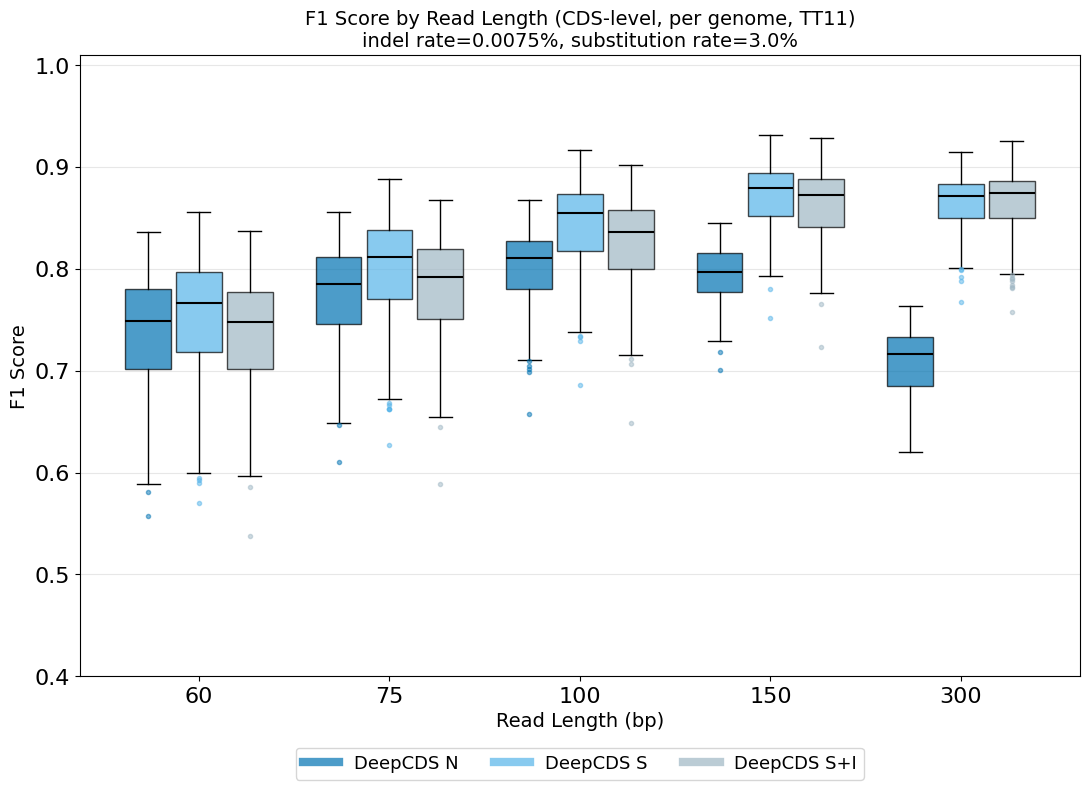

In [ ]:
def plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, metric_name, ylabel):
    """Plot per-genome metric distributions as grouped boxplots across read lengths.

    All models are shown in a single figure. For each read length, one box per model
    is drawn side by side (mirroring the grouped bar chart layout). Models with no
    data at any read length are skipped.

    Args:
        per_genome_metrics_list: Dict of {length: {model: {metric_name: [values_per_genome]}}}.
        read_lengths: List of read lengths for the x-axis.
        metric_name: Key into metrics (e.g. 'f1_score', 'precision', 'recall').
        ylabel: Y-axis label and part of the plot title.
    """
    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[l][m][metric_name] for l in read_lengths)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    fig, ax = plt.subplots(figsize=(11, 8))

    x_positions = np.arange(len(read_lengths))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = model_colors[model]
        positions, data = [], []
        for i, length in enumerate(read_lengths):
            vals = per_genome_metrics_list[length][model][metric_name]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=model_display_names[model])
        

    ax.set_xlabel('Read Length (bp)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(f'{ylabel} by Read Length (CDS-level, per genome, TT11)\n{error_rate_label}', fontsize = 14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(l) for l in read_lengths])
    ax.set_ylim(0.4, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=3) #-0.1 for merged plot; -0.07 for 30bp cutoff plot

    plt.tight_layout()
    #plt.savefig(f"cds_prediction_metrics_by_read_length_boxplot_{metric_name}.svg", dpi=500)
    # plt.savefig(f"cds_prediction_metrics_by_read_length_boxplot_{metric_name}.svg", dpi=500)
    plt.show()

plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'f1_score', 'F1 Score')
#plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'precision', 'Precision')
#plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'recall', 'Sensitivity')

In [ ]:
# Generate the LaTeX results table: 3 metric sections (F1, Sensitivity, Precision),
# rows = models, columns = read lengths. Best score per read length is bolded, decided on
# the point estimate alone.
#
# TWO versions are printed from the same numbers:
#   latex_table_with_std    - each cell is "estimate $\pm$ SE", the SE being the genome-level
#                             cluster bootstrap SE of that same pooled score (metrics_std,
#                             from the compute-metrics cell) - NOT a spread across genomes.
#   latex_table_without_std - point estimates only, for when the per-cell errors are too
#                             cluttered to typeset. The uncertainty is not thrown away: the
#                             caption reports, per model, the min--max of that model's SE
#                             across every cell of the table.

metrics_order = [
    ('f1_score', 'F1 Score'),
    ('recall', 'Sensitivity'),
    ('precision', 'Precision'),
]

# The toggle changes what the table IS (read lengths, model set and ground-truth set), so it
# gets its own label - otherwise the two runs of this notebook emit the same \label twice.
# NB: the base name is also used by cds_level_read_length_IoU_thresholds.ipynb; if both tables
# go into the same document, rename one of them.
_LABEL = 'tab:cds_read_length_with_errors' + ('_30bp' if run_30_bp_analysis else '')

_CAPTION_BASE = (
    'TODO: WRITE CAPTION. Aggregated CDS-level performance across all test genomes for each '
    'model and read length, counting a prediction as correct only on an exact coordinate and '
    'reading-frame match (IoU = 1). Values are pooled over all test genomes (TT4 genomes '
    'excluded for fair comparison). '
    + ('Evaluated against the $\\ge$30bp ground-truth set, which additionally contains CDS '
       'stretches of 30--60bp, and restricted to the DeepCDS models - the only ones with '
       'predictions available at 60bp. '
       if run_30_bp_analysis else
       'Evaluated against the $>$60bp ground-truth set. ')
    + 'Best score per read length is bolded.'
)


def _caption(show_std):
    """Caption text for either version of the table."""
    if show_std:
        return (_CAPTION_BASE + ' $\\pm$ is the standard error of that same pooled score '
                'from a genome-level cluster bootstrap (1000 replicates, resampling test '
                'genomes with replacement).')
    return (_CAPTION_BASE + ' Standard errors are omitted from the cells for readability; '
            'across all metrics and read lengths, the genome-level cluster bootstrap SE '
            '(1000 replicates, resampling test genomes with replacement) spans, per model: '
            + _se_ranges() + '.')


def _latex_escape(text):
    """Escape LaTeX specials in a model display name.

    MODEL_DISPLAY_NAMES is shared with the matplotlib plots, where a bare '%' is what you
    want - but in LaTeX '%' opens a comment and silently swallows the rest of the row,
    including its '\\\\' terminator (e.g. "FGS (0.5% error rate)" eats its own row). Escaping
    at table-build time fixes the table without changing what the plots render.
    """
    for _char in ('&', '%', '#', '_'):
        text = text.replace(_char, '\\' + _char)
    return text


def _se_ranges():
    """Per-model 'min--max' of the bootstrap SE over every cell of the table.

    Ranges span all metric sections and all read lengths, i.e. exactly the cells whose
    '$\\pm$ SE' the no-SE version of the table drops. Models with no data at all are omitted.
    """
    parts = []
    for model in model_names:
        ses = [metrics_std[model][key][i]
               for key, _ in metrics_order
               for i in range(len(read_lengths))
               if not np.isnan(metrics_std[model][key][i])]
        if ses:
            parts.append(f'{_latex_escape(model_display_names[model])} '
                         f'{min(ses):.3f}--{max(ses):.3f}')
    return '; '.join(parts)


def build_latex_table(show_std):
    """Build the read-length results table as one LaTeX string.

    Args:
        show_std: True  -> every cell reads 'estimate $\\pm$ SE'.
                  False -> cells carry the point estimate only, and the caption reports each
                           model's SE range instead, so the uncertainty is still on the page.

    Returns:
        The complete table environment as a single string.
    """
    col_fmt = 'l' + 'c' * len(read_lengths)
    header_cols = ' & '.join(f'{l}bp' for l in read_lengths)

    lines = []
    lines.append(r'\begin{table}[ht]')
    lines.append(r'\centering')
    lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
    lines.append(r'\toprule')
    lines.append(f' & {header_cols} ' + r'\\')

    for metric_key, metric_label in metrics_order:
        lines.append(r'\midrule')
        lines.append(rf'\multicolumn{{{1 + len(read_lengths)}}}{{l}}{{\textbf{{{metric_label}}}}} \\')
        lines.append(r'\midrule')

        # Best value per read length for this metric, on the point estimate alone.
        best_per_length = []
        for i in range(len(read_lengths)):
            valid = [aggregated_metrics[m][metric_key][i] for m in model_names
                     if not np.isnan(aggregated_metrics[m][metric_key][i])]
            best_per_length.append(max(valid) if valid else None)

        for model in model_names:
            vals = []
            for i in range(len(read_lengths)):
                v = aggregated_metrics[model][metric_key][i]
                std = metrics_std[model][metric_key][i]
                if np.isnan(v):
                    vals.append('--')
                    continue
                cell_text = f'{v:.3f}'
                if show_std and not np.isnan(std):
                    cell_text += f' $\\pm$ {std:.3f}'
                if best_per_length[i] is not None and v == best_per_length[i]:
                    cell_text = rf'\textbf{{{cell_text}}}'
                vals.append(cell_text)
            lines.append(f'{_latex_escape(model_display_names[model])} & '
                         + ' & '.join(vals) + r' \\')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(rf'\caption{{{_caption(show_std)}}}')
    lines.append(rf'\label{{{_LABEL if show_std else _LABEL + "_no_se"}}}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)


latex_table_with_std = build_latex_table(show_std=True)
latex_table_without_std = build_latex_table(show_std=False)

print('=' * 30, 'WITH per-cell SE', '=' * 30)
print(latex_table_with_std)
print()
print('=' * 30, 'WITHOUT per-cell SE (ranges in caption)', '=' * 30)
print(latex_table_without_std)

============================== WITH per-cell SE ==============================
\begin{table}[ht]
\centering
\begin{tabular}{lccccc}
\toprule
 & 60bp & 75bp & 100bp & 150bp & 300bp \\
\midrule
\multicolumn{6}{l}{\textbf{F1 Score}} \\
\midrule
DeepCDS N & 0.748 $\pm$ 0.004 & 0.784 $\pm$ 0.003 & 0.808 $\pm$ 0.002 & 0.801 $\pm$ 0.002 & 0.717 $\pm$ 0.002 \\
DeepCDS S & \textbf{0.765 $\pm$ 0.004} & \textbf{0.810 $\pm$ 0.003} & \textbf{0.851 $\pm$ 0.003} & \textbf{0.877 $\pm$ 0.002} & 0.871 $\pm$ 0.002 \\
DeepCDS S+I & 0.747 $\pm$ 0.004 & 0.791 $\pm$ 0.003 & 0.834 $\pm$ 0.003 & 0.869 $\pm$ 0.002 & \textbf{0.873 $\pm$ 0.002} \\
\midrule
\multicolumn{6}{l}{\textbf{Sensitivity}} \\
\midrule
DeepCDS N & 0.749 $\pm$ 0.004 & 0.769 $\pm$ 0.004 & 0.787 $\pm$ 0.003 & 0.777 $\pm$ 0.002 & 0.720 $\pm$ 0.002 \\
DeepCDS S & 0.765 $\pm$ 0.004 & 0.797 $\pm$ 0.004 & 0.831 $\pm$ 0.003 & 0.853 $\pm$ 0.003 & 0.862 $\pm$ 0.002 \\
DeepCDS S+I & \textbf{0.806 $\pm$ 0.004} & \textbf{0.824 $\pm$ 0.003} & \textbf{0.84